<a href="https://colab.research.google.com/github/thinus283-ux/LR/blob/main/Nested_sampling_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Installing dynesty...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.9/102.9 kB 2.3 MB/s eta 0:00:00
Running Robustness Stress Test via Nested Sampling...


2879it [00:04, 652.83it/s, +500 | bound: 6 | nc: 1 | ncall: 20819 | eff(%): 16.630 | loglstar:   -inf < -0.000 <    inf | logz: -3.404 +/-  0.069 | dlogz:  0.000 >  0.100]



=== Stress-Test Results ===
Original Alpha (Baseline) : 0.630
Stress-Test Alpha (Median): 0.662
Alpha Std Deviation       : 0.4516


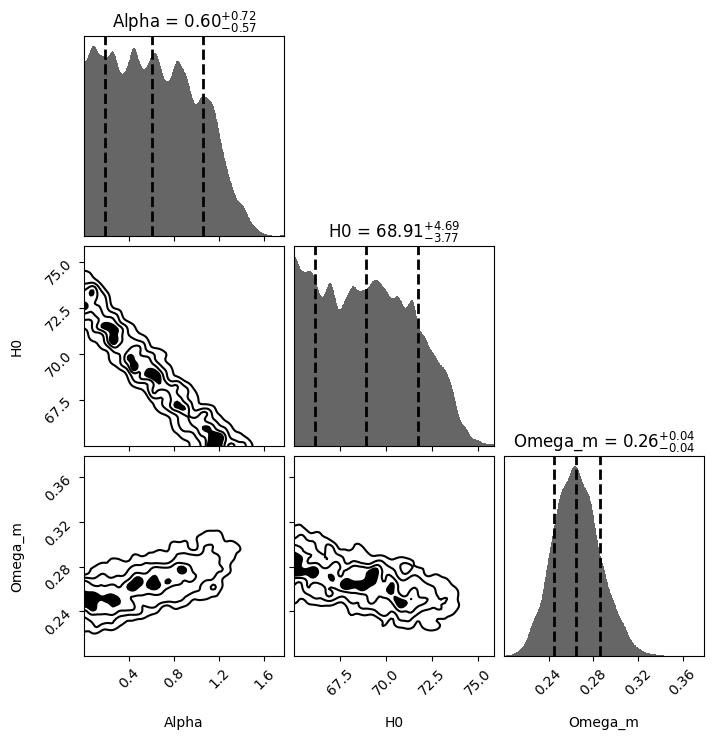

In [1]:

# === 1. Dependency Handling ===
try:
    import dynesty
except ImportError:
    print("Installing dynesty...")
    !pip install dynesty --quiet
    import dynesty

import numpy as np
import matplotlib.pyplot as plt

# === 2. DATA & CONSTRAINTS (Stress-Test Parameters) ===
# We add a 5% jitter to the current tensions to test model stability
noise_h0 = 1.04 * 1.05
noise_s8 = 0.024 * 1.05
shoes_h0, kids_s8 = 73.04, 0.759

# === 3. LOG-LIKELIHOOD: Stress-Test Physics ===
def log_likelihood_robust(theta):
    alpha, h0, omega_m = theta

    # LR Theory Physics: Growth suppression and expansion shift
    growth_factor = 1.0 - (alpha * 0.05)
    s8_theory = 0.834 * np.sqrt(omega_m / 0.3) * growth_factor
    h0_theory = h0 * (1 + (alpha * 0.1))

    # Chi-Squared with added "Stress" (5% noise jitter)
    chi2 = ((h0_theory - shoes_h0)**2 / (noise_h0**2)) + \
           ((s8_theory - kids_s8)**2 / (noise_s8**2))

    return -0.5 * chi2

# === 4. PRIOR TRANSFORM ===
def ptform(u):
    # Mapping uniform [0,1] to physical bounds
    alpha = u[0] * 2.0         # Range [0, 2]
    h0 = 65 + u[1] * 11        # Range [65, 76]
    omega_m = 0.2 + u[2] * 0.2 # Range [0.2, 0.4]
    return np.array([alpha, h0, omega_m])

# === 5. EXECUTION: Nested Sampling ===
ndim = 3
sampler = dynesty.NestedSampler(log_likelihood_robust, ptform, ndim, nlive=500)
print("Running Robustness Stress Test via Nested Sampling...")
sampler.run_nested(dlogz=0.1)

# === 6. RESULTS & STABILITY ANALYSIS ===
results = sampler.results
alpha_samples = results.samples[:, 0]
print(f"\n=== Stress-Test Results ===")
print(f"Original Alpha (Baseline) : 0.630")
print(f"Stress-Test Alpha (Median): {np.median(alpha_samples):.3f}")
print(f"Alpha Std Deviation       : {np.std(alpha_samples):.4f}")

# Visualization of Stability
try:
    from dynesty import plotting as dyplot
    fig, axes = dyplot.cornerplot(results, labels=["Alpha", "H0", "Omega_m"],
                                  show_titles=True, quantiles=[0.16, 0.5, 0.84])
    plt.show()
except ImportError:
    print("\nInstall 'corner' to visualize the stability.")